# L'ANOMALIE DU PLUS HAUT DE 52 SEMAINES

## Objectif du notebook

Ce notebook transforme le concept EBTA du **plus haut de 52 semaines** en une idée testable avec Python.

L'objectif n'est pas de prouver définitivement l'anomalie, mais de comprendre :

- **quoi mesurer** ;
- **pourquoi cette mesure pourrait prédire les rendements futurs** ;
- **comment coder une règle simple** ;
- **comment comparer cette règle à un momentum classique** ;
- **quelles erreurs éviter avant de croire qu'on a trouvé un edge**.

> L'Eurêka final : le prix proche de son plus haut annuel n'est pas seulement un prix 'haut'.  
> Dans l'approche EBTA, il peut représenter une **ancre psychologique** qui retarde l'ajustement du marché, puis crée une dérive exploitable.

## 1. L'idée centrale

L'anomalie du **plus haut de 52 semaines** affirme que la proximité du prix actuel avec son plus haut annuel peut contenir de l'information sur les rendements futurs.

On définit généralement la proximité au plus haut de 52 semaines ainsi :

$$
\text{Proximité}_{t} = \frac{P_t}{\max(P_{t-251}, \ldots, P_t)}
$$

Où :

- $P_t$ est le prix actuel ;
- le dénominateur est le plus haut prix observé sur environ **252 séances**, soit une année boursière ;
- une valeur proche de $1$ signifie que le titre est proche de son plus haut annuel.

Exemple :

| Prix actuel | Plus haut 52 semaines | Proximité |
|---:|---:|---:|
| 95 | 100 | 0.95 |
| 99 | 100 | 0.99 |
| 101 | 101 | 1.00 |

Plus la proximité est élevée, plus le titre est proche de son **ancre psychologique majeure**.

## 2. Pourquoi cela contredit la forme faible de l'EMH ?

La forme faible de l'**Hypothèse d'Efficience des Marchés** affirme que les prix passés ne devraient pas permettre de prédire les rendements futurs.

Or, le plus haut de 52 semaines est une information entièrement issue du **passé du prix**.

Si cette variable permet de prédire les rendements futurs, alors cela signifie que les prix passés ne sont pas totalement inutiles.

> Ce n'est pas une preuve que 'tout marche' en analyse technique.  
> C'est plutôt une preuve qu'une **analyse technique objective, testable et statistique** peut parfois capturer une structure non aléatoire.

## 3. Mécanisme comportemental : ancrage et sous-réaction

L'explication comportementale repose sur deux idées :

### Biais d'ancrage

Les investisseurs utilisent certains niveaux historiques comme références mentales.

Le plus haut annuel devient une phrase implicite :

> 'Ce titre est déjà très cher.'

Même si de bonnes nouvelles arrivent, certains investisseurs hésitent à acheter au-dessus de ce niveau.

### Sous-réaction

Cette hésitation ralentit l'ajustement du prix vers sa valeur rationnelle.

Le marché ne corrige pas instantanément toute l'information positive.

La conséquence possible est une **dérive haussière** après la cassure ou l'approche du plus haut annuel.

| Étape | Comportement | Effet possible sur le prix |
|---|---|---|
| Bonne nouvelle | Les fondamentaux s'améliorent | Le prix devrait monter |
| Prix proche du plus haut | Les investisseurs hésitent | Sous-réaction |
| Cassure de l'ancre | L'hésitation diminue | Momentum |
| Correction progressive | Le prix rattrape la valeur | Rendement futur positif |

## 4. Traduction en stratégie testable

On peut transformer l'idée en règle simple :

### Règle 1 — Signal 52-week high

Acheter quand :

$$
\frac{P_t}{\max(P_{t-251}, \ldots, P_t)} > 0.95
$$

Cela signifie :

> Le prix actuel est dans les **5\%** supérieurs de son canal annuel.

### Règle 2 — Momentum classique

Comparer avec un momentum sur 12 mois :

$$
\text{Momentum}_{t} = \frac{P_t}{P_{t-252}} - 1
$$

Acheter les titres dont le momentum passé est positif.

### Ce que l'on veut comparer

| Méthode | Variable utilisée | Question posée |
|---|---|---|
| 52-week high | Distance au plus haut annuel | Le titre est-il proche de son ancre ? |
| Momentum 12 mois | Rendement passé | Le titre a-t-il monté sur 12 mois ? |

La subtilité est importante : deux titres peuvent avoir le même momentum passé, mais une position très différente par rapport à leur plus haut annuel.

## 5. Téléchargement des données réelles via yfinance

On utilise ici de **vraies données de marché** téléchargées via `yfinance`.

L'univers retenu est composé de :
- Les **11 ETFs sectoriels SPDR** (couverture complète du S&P 500 par secteur)
- Les **grandes capitalisations** emblématiques du marché américain

Ces données sont ajustées pour les splits et dividendes (`auto_adjust=True`).

> **Remarque** : La période choisie est 2018–2024 (6 ans), ce qui permet de couvrir plusieurs cycles de marché, incluant la correction COVID de 2020 et le marché haussier post-pandémie.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

# ── Univers de titres ──────────────────────────────────────────────────────
# ETFs sectoriels SPDR (représentatifs du marché US)
spdr_etfs = [
    "XLK",   # Technology
    "XLF",   # Financials
    "XLV",   # Health Care
    "XLY",   # Consumer Discretionary
    "XLP",   # Consumer Staples
    "XLE",   # Energy
    "XLI",   # Industrials
    "XLB",   # Materials
    "XLRE",  # Real Estate
    "XLU",   # Utilities
    "XLC",   # Communication Services
]

# Grandes capitalisations US (Magnificent 7 + autres blue chips)
large_caps = [
    "AAPL",  # Apple
    "MSFT",  # Microsoft
    "NVDA",  # NVIDIA
    "AMZN",  # Amazon
    "GOOGL", # Alphabet
    "META",  # Meta
    "TSLA",  # Tesla
    "JPM",   # JPMorgan Chase
    "JNJ",   # Johnson & Johnson
    "V",     # Visa
    "WMT",   # Walmart
    "PG",    # Procter & Gamble
    "HD",    # Home Depot
    "MA",    # Mastercard
    "UNH",   # UnitedHealth
    "COST",  # Costco
    "LLY",   # Eli Lilly
    "AVGO",  # Broadcom
    "BAC",   # Bank of America
    "XOM",   # ExxonMobil
]

tickers = spdr_etfs + large_caps

# ── Téléchargement des données ─────────────────────────────────────────────
START_DATE = "2018-01-01"
END_DATE   = "2024-12-31"

print(f"Téléchargement de {len(tickers)} titres du {START_DATE} au {END_DATE}...")
raw = yf.download(
    tickers,
    start=START_DATE,
    end=END_DATE,
    auto_adjust=True,
    progress=False
)

# On utilise les prix de clôture ajustés
prices = raw["Close"].dropna(how="all", axis=1)
prices = prices.dropna(how="all", axis=0)

# Suppression des colonnes avec trop de données manquantes (> 10 %)
threshold_missing = 0.10
valid_cols = prices.isnull().mean() < threshold_missing
prices = prices.loc[:, valid_cols]

# Remplissage des trous résiduels par forward-fill
prices = prices.ffill()

assets = list(prices.columns)
print(f"\n✅ {len(assets)} titres retenus : {assets}")
print(f"📅 Période : {prices.index[0].date()} → {prices.index[-1].date()}")
print(f"📊 Nombre de séances : {len(prices)}")

prices.tail(3)

Téléchargement de 31 titres du 2018-01-01 au 2024-12-31...

✅ 31 titres retenus : ['AAPL', 'AMZN', 'AVGO', 'BAC', 'COST', 'GOOGL', 'HD', 'JNJ', 'JPM', 'LLY', 'MA', 'META', 'MSFT', 'NVDA', 'PG', 'TSLA', 'UNH', 'V', 'WMT', 'XLB', 'XLC', 'XLE', 'XLF', 'XLI', 'XLK', 'XLP', 'XLRE', 'XLU', 'XLV', 'XLY', 'XOM']
📅 Période : 2018-01-02 → 2024-12-30
📊 Nombre de séances : 1760


Ticker,AAPL,AMZN,AVGO,BAC,COST,GOOGL,HD,JNJ,JPM,LLY,...,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2024-12-26,257.375610,227.050003,242.653671,43.072983,948.502563,194.583664,380.116791,139.705627,235.823608,785.594666,...,40.652626,48.188148,132.068954,119.451431,77.136940,39.245575,36.833008,136.625366,115.565979,101.351982
2024-12-27,253.967392,223.750000,239.083496,42.869942,932.194031,191.758408,377.923492,139.197021,233.912903,774.742798,...,40.647820,47.834908,131.085266,117.863312,76.759438,38.928696,36.726807,135.989197,113.656357,101.342461
2024-12-30,250.598907,221.300003,232.981552,42.454205,914.843689,190.246323,374.623932,137.556015,232.118561,765.513184,...,40.643013,47.373726,129.767136,116.364525,75.859230,38.746246,36.572330,134.315643,111.830849,100.657204


## 6. Calcul de la proximité au plus haut de 52 semaines

On calcule :

$$
\text{Proximité}_{t} = \frac{P_t}{H_{52,t}}
$$

avec :

$$
H_{52,t} = \max(P_{t-251}, \ldots, P_t)
$$

Une proximité de $0.98$ signifie que le prix est seulement à $2\%$ de son plus haut annuel.

In [2]:
lookback = 252

rolling_high_52w = prices.rolling(lookback).max()
proximity_52w = prices / rolling_high_52w

momentum_12m = prices / prices.shift(lookback) - 1

print("Proximité au plus haut de 52 semaines (dernières valeurs) :")
print(proximity_52w.tail(3).round(4))

Proximité au plus haut de 52 semaines (dernières valeurs) :
Ticker        AAPL    AMZN    AVGO     BAC    COST   GOOGL      HD     JNJ  \
Date                                                                         
2024-12-26  1.0000  0.9748  0.9841  0.9378  0.9612  0.9946  0.9160  0.8767   
2024-12-27  0.9868  0.9606  0.9696  0.9334  0.9447  0.9802  0.9107  0.8735   
2024-12-30  0.9737  0.9501  0.9448  0.9243  0.9271  0.9724  0.9028  0.8632   

Ticker         JPM     LLY  ...     XLE     XLF     XLI     XLK     XLP  \
Date                        ...                                           
2024-12-26  0.9714  0.8286  ...  0.8767  0.9606  0.9371  0.9985  0.9580   
2024-12-27  0.9636  0.8171  ...  0.8766  0.9536  0.9301  0.9853  0.9533   
2024-12-30  0.9562  0.8074  ...  0.8765  0.9444  0.9208  0.9727  0.9421   

Ticker        XLRE     XLU     XLV     XLY     XOM  
Date                                                
2024-12-26  0.9137  0.9277  0.8952  0.9775  0.8564  
2024-12-27  0.

## 7. Visualiser l'ancre du plus haut annuel sur un actif réel

On affiche pour **NVIDIA (NVDA)** :

- le prix de clôture ajusté ;
- le plus haut roulant de 52 semaines ;
- les périodes où le prix est proche de ce plus haut (proximité > 0.95).

> NVDA est un exemple particulièrement illustratif car il a connu plusieurs cassures majeures de ses plus hauts 52 semaines, notamment en 2023–2024 avec la vague IA.

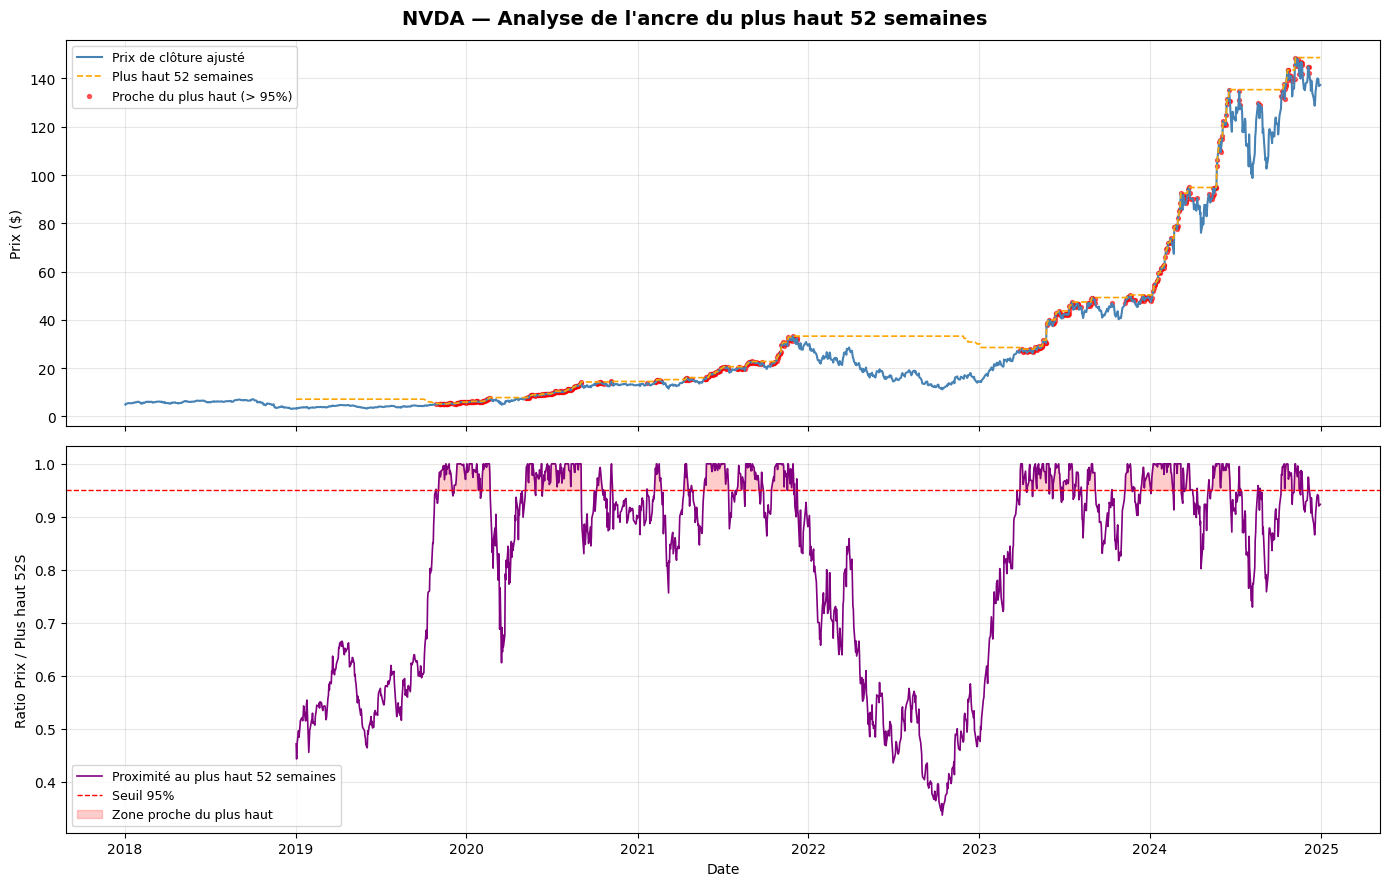

In [3]:
# Sélection de l'actif à visualiser
asset = "NVDA" if "NVDA" in assets else assets[-1]

threshold = 0.95
near_high = proximity_52w[asset] > threshold

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
fig.suptitle(f"{asset} — Analyse de l'ancre du plus haut 52 semaines", fontsize=14, fontweight='bold')

# ── Graphe 1 : Prix et plus haut 52 semaines ──
ax1 = axes[0]
ax1.plot(prices.index, prices[asset], label="Prix de clôture ajusté", color='steelblue', lw=1.5)
ax1.plot(rolling_high_52w.index, rolling_high_52w[asset],
         label="Plus haut 52 semaines", color='orange', lw=1.2, linestyle='--')
ax1.scatter(prices.index[near_high], prices[asset][near_high],
            s=8, color='red', alpha=0.6, label=f"Proche du plus haut (> {threshold:.0%})")
ax1.set_ylabel("Prix ($)")
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# ── Graphe 2 : Proximité au plus haut ──
ax2 = axes[1]
ax2.plot(proximity_52w.index, proximity_52w[asset],
         color='purple', lw=1.2, label="Proximité au plus haut 52 semaines")
ax2.axhline(threshold, color='red', linestyle='--', lw=1, label=f"Seuil {threshold:.0%}")
ax2.fill_between(proximity_52w.index, proximity_52w[asset], threshold,
                 where=proximity_52w[asset] > threshold,
                 alpha=0.2, color='red', label="Zone proche du plus haut")
ax2.set_ylabel("Ratio Prix / Plus haut 52S")
ax2.set_xlabel("Date")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7b. Vue d'ensemble : proximité actuelle de tous les titres

On visualise la proximité de **chaque titre** par rapport à son plus haut de 52 semaines à la **dernière date disponible**.

Cela donne une photographie instantanée de l'univers : quels titres sont proches de leur ancre psychologique ?

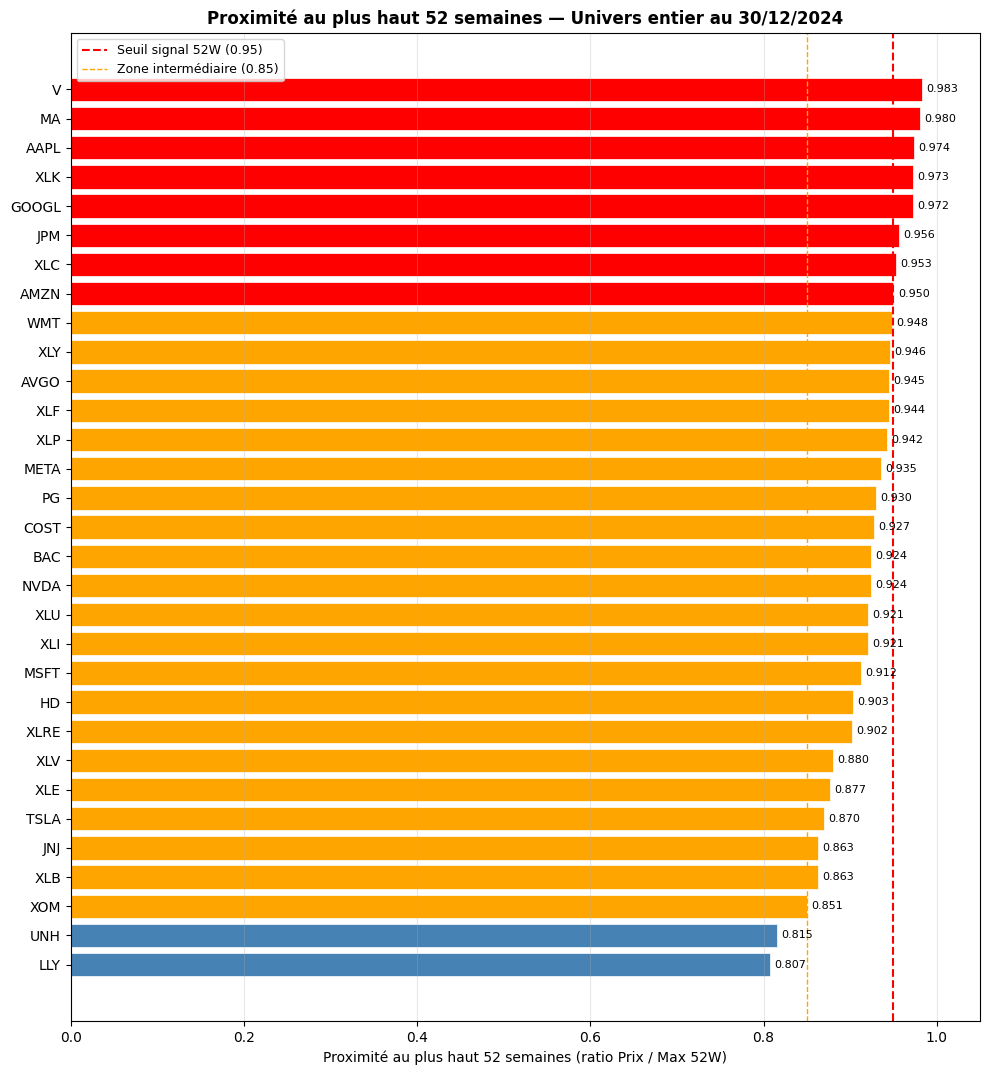


Titres proches du plus haut (> 95%) au 30/12/2024 :
        Proximité
Ticker           
V          0.9825
MA         0.9802
AAPL       0.9737
XLK        0.9727
GOOGL      0.9724
JPM        0.9562
XLC        0.9532
AMZN       0.9501


In [4]:
last_proximity = proximity_52w.iloc[-1].sort_values(ascending=True).dropna()
last_date = proximity_52w.index[-1].strftime("%d/%m/%Y")

colors = [
    'red' if v > 0.95 else ('orange' if v > 0.85 else 'steelblue')
    for v in last_proximity.values
]

fig, ax = plt.subplots(figsize=(10, max(6, len(last_proximity) * 0.35)))
bars = ax.barh(last_proximity.index, last_proximity.values, color=colors, edgecolor='white', lw=0.5)
ax.axvline(0.95, color='red', linestyle='--', lw=1.5, label="Seuil signal 52W (0.95)")
ax.axvline(0.85, color='orange', linestyle='--', lw=1, label="Zone intermédiaire (0.85)")
ax.set_xlabel("Proximité au plus haut 52 semaines (ratio Prix / Max 52W)")
ax.set_title(f"Proximité au plus haut 52 semaines — Univers entier au {last_date}",
             fontweight='bold')
ax.set_xlim(0, 1.05)
ax.legend(fontsize=9)

# Ajout des valeurs
for bar, val in zip(bars, last_proximity.values):
    ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va='center', fontsize=8)

ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nTitres proches du plus haut (> 95%) au {last_date} :")
print(last_proximity[last_proximity > 0.95].sort_values(ascending=False).to_frame("Proximité").round(4))

## 8. Construire deux portefeuilles simples

Nous allons comparer deux approches sur les données réelles.

### Portefeuille A — 52-week high

Chaque mois, on sélectionne les actifs dont la proximité au plus haut annuel est supérieure à $0.95$.

### Portefeuille B — Momentum 12 mois

Chaque mois, on sélectionne les actifs dont le momentum 12 mois est positif.

Pour garder l'exemple simple :

- pondération égale entre les actifs sélectionnés ;
- rebalancement mensuel ;
- pas de vente à découvert ;
- pas de frais de transaction dans la première version.

In [5]:
daily_returns = prices.pct_change()

# Dates de rebalancement mensuel
rebalance_dates = prices.resample("ME").last().index
rebalance_dates = rebalance_dates.intersection(prices.index)

def build_monthly_rebalanced_weights(signal: pd.DataFrame, rebalance_dates: pd.DatetimeIndex) -> pd.DataFrame:
    weights = pd.DataFrame(0.0, index=signal.index, columns=signal.columns)

    for date in rebalance_dates:
        selected = signal.loc[date].fillna(False)
        n_selected = int(selected.sum())

        if n_selected > 0:
            weights.loc[date, selected.index[selected]] = 1 / n_selected

    # Les poids sont tenus jusqu'au prochain rebalancement
    weights = weights.replace(0, np.nan).ffill().fillna(0)

    # Décalage d'un jour pour éviter le look-ahead bias
    weights = weights.shift(1).fillna(0)

    return weights

signal_52w      = proximity_52w > 0.95
signal_momentum = momentum_12m > 0

weights_52w      = build_monthly_rebalanced_weights(signal_52w, rebalance_dates)
weights_momentum = build_monthly_rebalanced_weights(signal_momentum, rebalance_dates)

portfolio_returns_52w      = (weights_52w * daily_returns).sum(axis=1)
portfolio_returns_momentum = (weights_momentum * daily_returns).sum(axis=1)

equity_52w      = (1 + portfolio_returns_52w).cumprod()
equity_momentum = (1 + portfolio_returns_momentum).cumprod()

comparison = pd.DataFrame({
    "52-week high": equity_52w,
    "Momentum 12 mois": equity_momentum
})

comparison.tail()

,52-week high,Momentum 12 mois
Date,,
2024-12-23,9.558367,5.722796
2024-12-24,9.747793,5.791479
2024-12-26,9.749674,5.792529
2024-12-27,9.588806,5.733505
2024-12-30,9.410474,5.668984


## 9. Comparaison visuelle des deux stratégies

La courbe suivante permet de comparer la croissance d'un capital initial de $1$.

Les données étant **réelles**, ce résultat est un vrai backtest sur l'univers retenu — même si les biais habituels (survivorship bias, look-ahead, coûts) doivent toujours être considérés.

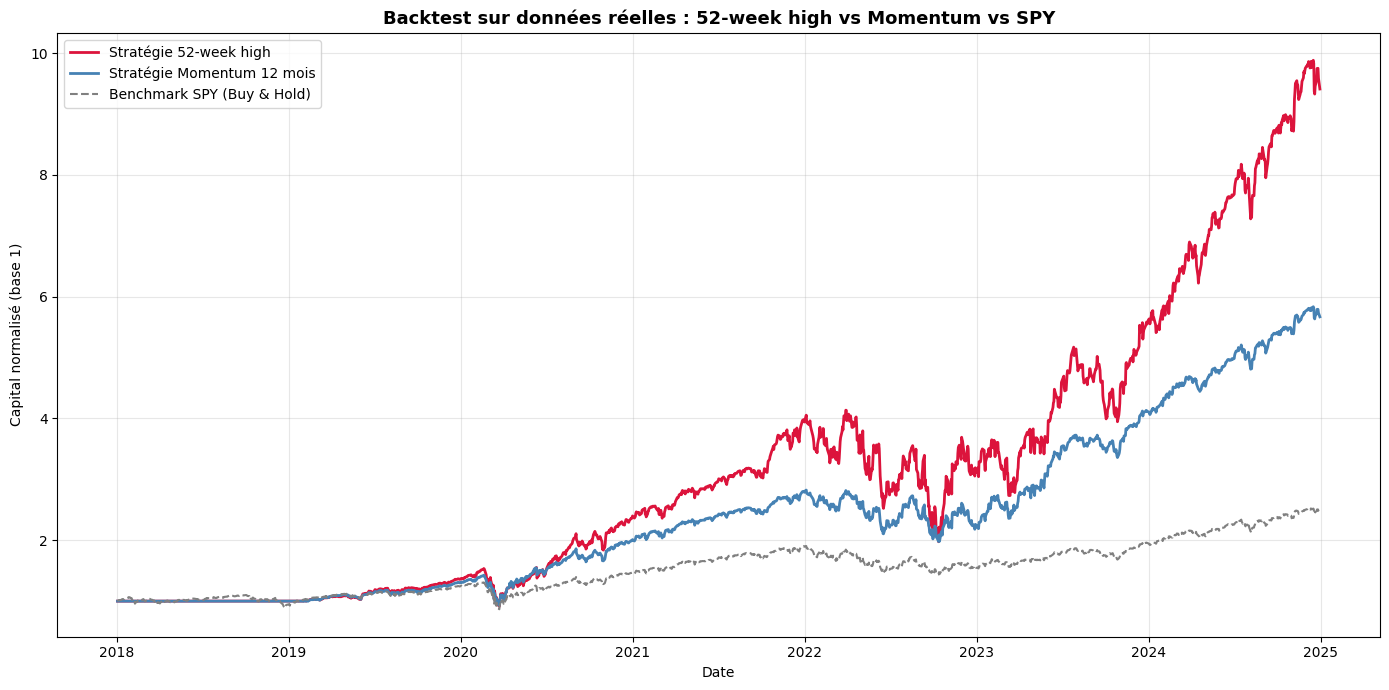

In [6]:
# Ajout du benchmark S&P 500 (SPY)
spy_raw = yf.download("SPY", start=START_DATE, end=END_DATE, auto_adjust=True, progress=False)
spy_close = spy_raw["Close"].squeeze().reindex(prices.index).ffill()
spy_ret   = spy_close.pct_change().fillna(0)
spy_equity = (1 + spy_ret).cumprod()

plt.figure(figsize=(14, 7))
plt.plot(comparison.index, comparison["52-week high"],
         label="Stratégie 52-week high", color='crimson', lw=2)
plt.plot(comparison.index, comparison["Momentum 12 mois"],
         label="Stratégie Momentum 12 mois", color='steelblue', lw=2)
plt.plot(spy_equity.index, spy_equity,
         label="Benchmark SPY (Buy & Hold)", color='gray', lw=1.5, linestyle='--')

plt.title("Backtest sur données réelles : 52-week high vs Momentum vs SPY",
          fontsize=13, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Capital normalisé (base 1)")
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Mesures de performance

On calcule quelques métriques simples :

- rendement annualisé ;
- volatilité annualisée ;
- Sharpe ratio ;
- maximum drawdown.

Ces métriques ne suffisent pas pour valider scientifiquement une stratégie, mais elles donnent un premier diagnostic.

In [7]:
def performance_stats(returns: pd.Series, periods_per_year: int = 252) -> pd.Series:
    returns = returns.dropna()
    equity = (1 + returns).cumprod()

    total_return  = equity.iloc[-1] - 1
    years         = len(returns) / periods_per_year
    annual_return = (1 + total_return) ** (1 / years) - 1 if years > 0 else np.nan
    annual_vol    = returns.std() * np.sqrt(periods_per_year)
    sharpe        = annual_return / annual_vol if annual_vol != 0 else np.nan

    running_max = equity.cummax()
    drawdown    = equity / running_max - 1
    max_drawdown = drawdown.min()

    return pd.Series({
        "Rendement total":       total_return,
        "Rendement annualisé":   annual_return,
        "Volatilité annualisée": annual_vol,
        "Sharpe ratio":          sharpe,
        "Max drawdown":          max_drawdown
    })

stats = pd.DataFrame({
    "52-week high":    performance_stats(portfolio_returns_52w),
    "Momentum 12 mois": performance_stats(portfolio_returns_momentum),
    "SPY (benchmark)": performance_stats(spy_ret)
})

stats.applymap(lambda x: f"{x:.2%}" if abs(x) < 10 else f"{x:.2f}")

,52-week high,Momentum 12 mois,SPY (benchmark)
Rendement total,841.05%,466.90%,145.10%
Rendement annualisé,37.85%,28.20%,13.70%
Volatilité annualisée,38.35%,24.81%,19.46%
Sharpe ratio,98.70%,113.67%,70.38%
Max drawdown,-52.24%,-34.87%,-33.72%


## 11. Ajouter des coûts de transaction

Une erreur fréquente est de tester un signal brut sans tenir compte des coûts.

On ajoute ici un coût simple à chaque changement de poids :

$$
\text{Coût}_{t} = c \times \sum_i |w_{i,t} - w_{i,t-1}|
$$

Où $c$ représente le coût par unité de turnover.

Exemple :

- $c = 0.001$ représente environ $0.10\%$ ;
- si le portefeuille tourne beaucoup, le coût peut détruire le signal.

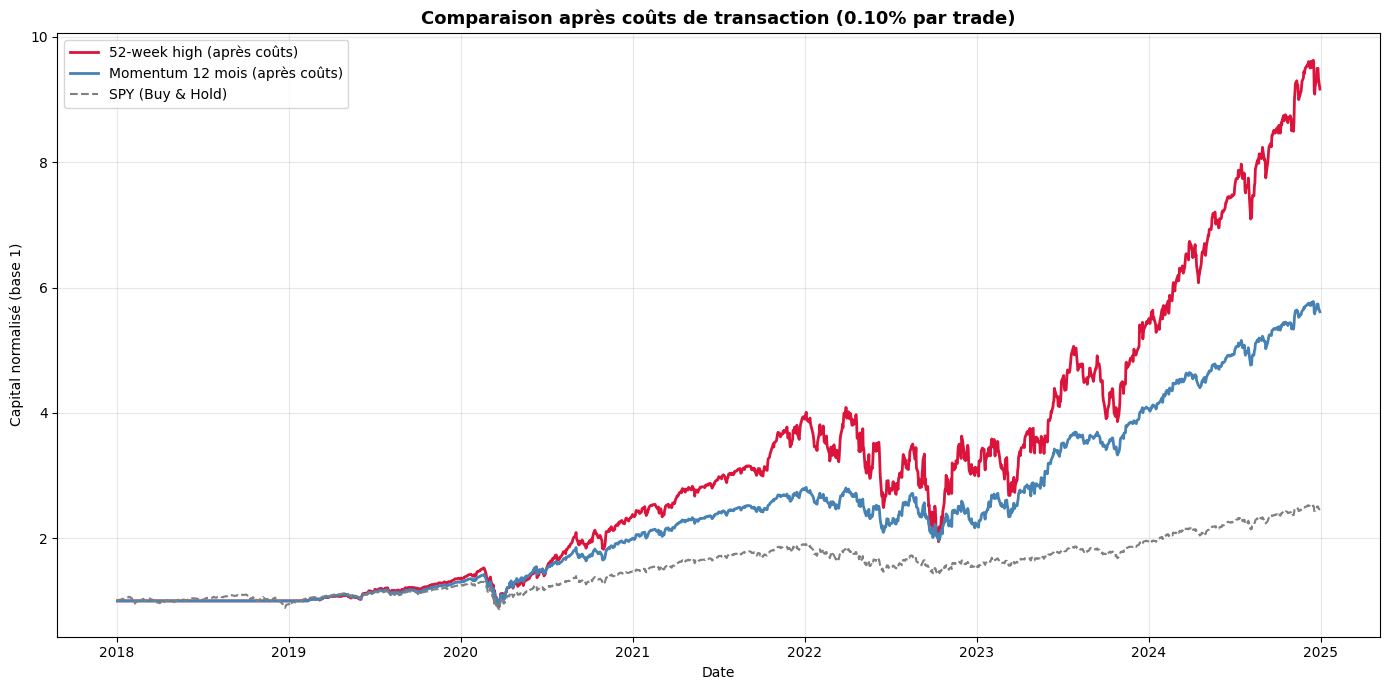


Statistiques après coûts de transaction :


,52-week high net,Momentum net,SPY (benchmark)
Rendement total,816.76%,461.35%,145.10%
Rendement annualisé,37.33%,28.02%,13.70%
Volatilité annualisée,38.34%,24.81%,19.46%
Sharpe ratio,97.37%,112.93%,70.38%
Max drawdown,-52.40%,-34.87%,-33.72%


In [8]:
transaction_cost = 0.001

def apply_transaction_costs(portfolio_returns: pd.Series, weights: pd.DataFrame, cost: float) -> pd.Series:
    turnover    = weights.diff().abs().sum(axis=1)
    net_returns = portfolio_returns - cost * turnover
    return net_returns

net_returns_52w      = apply_transaction_costs(portfolio_returns_52w, weights_52w, transaction_cost)
net_returns_momentum = apply_transaction_costs(portfolio_returns_momentum, weights_momentum, transaction_cost)

net_equity = pd.DataFrame({
    "52-week high net":  (1 + net_returns_52w).cumprod(),
    "Momentum net":      (1 + net_returns_momentum).cumprod(),
    "SPY (benchmark)":   spy_equity
})

plt.figure(figsize=(14, 7))
plt.plot(net_equity.index, net_equity["52-week high net"],
         label="52-week high (après coûts)", color='crimson', lw=2)
plt.plot(net_equity.index, net_equity["Momentum net"],
         label="Momentum 12 mois (après coûts)", color='steelblue', lw=2)
plt.plot(net_equity.index, net_equity["SPY (benchmark)"],
         label="SPY (Buy & Hold)", color='gray', lw=1.5, linestyle='--')
plt.title("Comparaison après coûts de transaction (0.10% par trade)",
          fontsize=13, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Capital normalisé (base 1)")
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Stats après coûts
stats_net = pd.DataFrame({
    "52-week high net":  performance_stats(net_returns_52w),
    "Momentum net":      performance_stats(net_returns_momentum),
    "SPY (benchmark)":   performance_stats(spy_ret)
})
print("\nStatistiques après coûts de transaction :")
stats_net.applymap(lambda x: f"{x:.2%}" if abs(x) < 10 else f"{x:.2f}")

## 12. Version orientée trading : breakout du plus haut de 52 semaines

Sur un seul actif réel, on teste une règle plus directe :

### Entrée

Acheter quand le prix casse son ancien plus haut de 52 semaines.

Pour éviter le **look-ahead bias**, on compare le prix actuel avec le plus haut connu jusqu'à la veille :

$$
H_{52,t-1} = \max(P_{t-252}, \ldots, P_{t-1})
$$

Signal :

$$
P_t > H_{52,t-1}
$$

### Sortie simple

Sortir si le prix passe sous une moyenne mobile à 50 jours.

Cette règle n'est pas forcément optimale, mais elle permet de rendre l'anomalie exploitable en logique de trading.

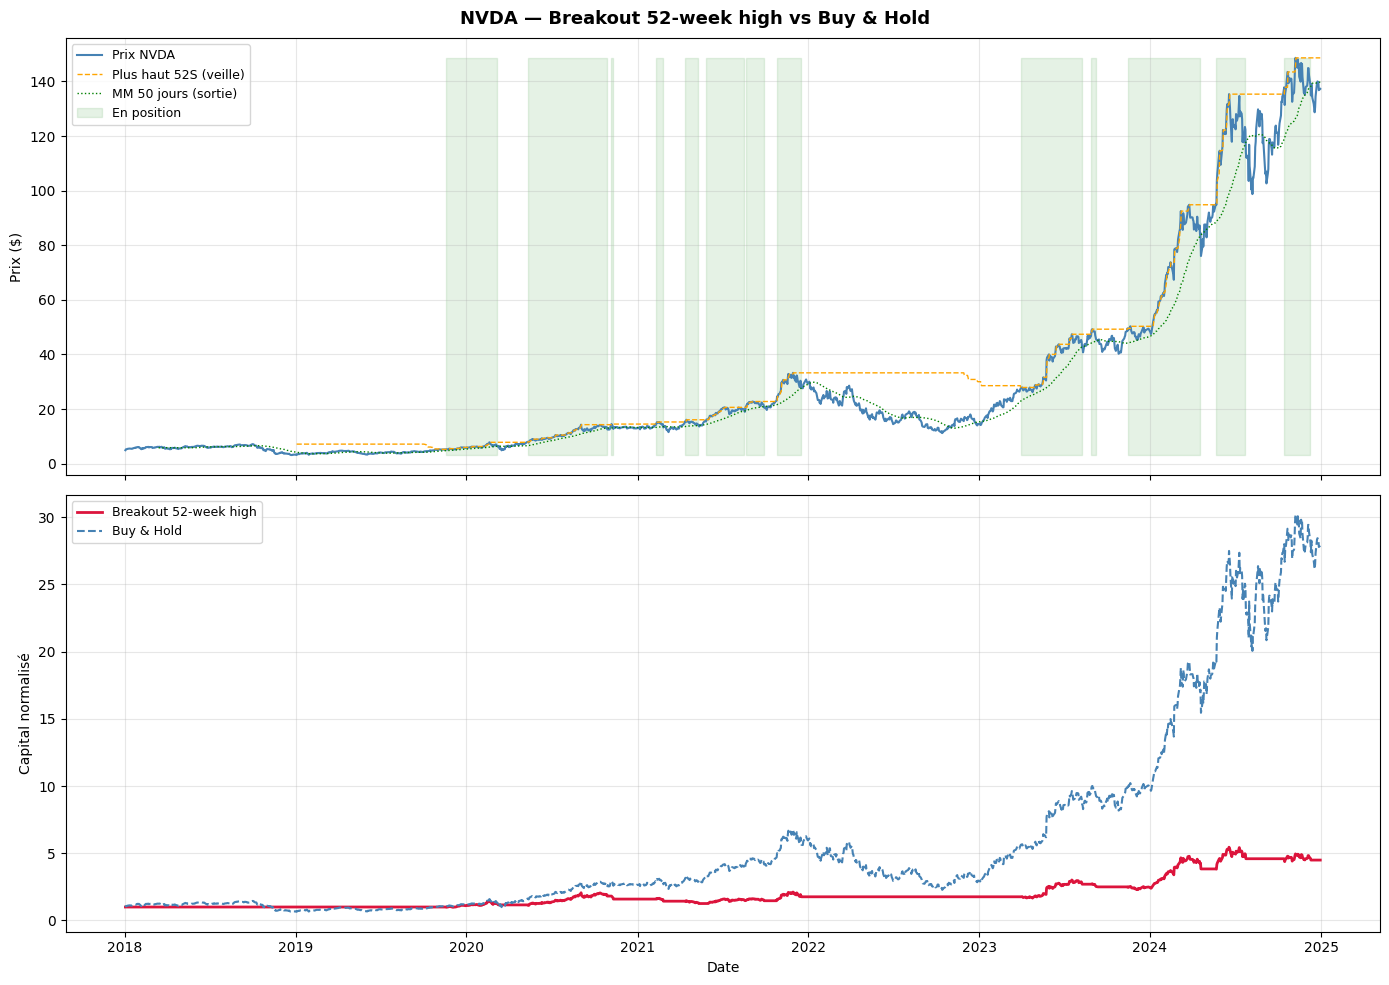

,Breakout 52W (NVDA),Buy & Hold (NVDA)
Rendement total,349.35%,26.89
Rendement annualisé,24.02%,61.09%
Volatilité annualisée,28.63%,51.54%
Sharpe ratio,83.89%,118.53%
Max drawdown,-38.96%,-66.34%


In [9]:
# On choisit NVDA comme exemple de cassure de plus haut 52 semaines
asset = "NVDA" if "NVDA" in assets else assets[-1]

price             = prices[asset]
previous_52w_high = price.shift(1).rolling(252).max()
ma_50             = price.rolling(50).mean()

entries = price > previous_52w_high
exits   = price < ma_50

position     = pd.Series(0, index=price.index, dtype=float)
in_position  = False

for i in range(len(price)):
    if not in_position and entries.iloc[i]:
        in_position = True
    elif in_position and exits.iloc[i]:
        in_position = False
    position.iloc[i] = 1.0 if in_position else 0.0

strategy_returns  = position.shift(1).fillna(0) * price.pct_change()
buy_hold_returns  = price.pct_change()

strategy_equity   = (1 + strategy_returns.fillna(0)).cumprod()
buy_hold_equity   = (1 + buy_hold_returns.fillna(0)).cumprod()

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
fig.suptitle(f"{asset} — Breakout 52-week high vs Buy & Hold",
             fontsize=13, fontweight='bold')

# ── Panel 1 : Prix + signaux ──
ax1 = axes[0]
ax1.plot(price.index, price, label=f"Prix {asset}", color='steelblue', lw=1.5)
ax1.plot(previous_52w_high.index, previous_52w_high,
         label="Plus haut 52S (veille)", color='orange', lw=1, linestyle='--')
ax1.plot(ma_50.index, ma_50, label="MM 50 jours (sortie)", color='green', lw=1, linestyle=':')

# Zones en position
in_pos_idx = position[position == 1].index
if len(in_pos_idx) > 0:
    ax1.fill_between(price.index, price.min(), price.max(),
                     where=position == 1, alpha=0.1, color='green', label="En position")
ax1.set_ylabel("Prix ($)")
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# ── Panel 2 : Equity curves ──
ax2 = axes[1]
ax2.plot(strategy_equity.index, strategy_equity,
         label="Breakout 52-week high", color='crimson', lw=2)
ax2.plot(buy_hold_equity.index, buy_hold_equity,
         label="Buy & Hold", color='steelblue', lw=1.5, linestyle='--')
ax2.set_ylabel("Capital normalisé")
ax2.set_xlabel("Date")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Comparaison des stats
stats_breakout = pd.DataFrame({
    f"Breakout 52W ({asset})": performance_stats(strategy_returns.dropna()),
    f"Buy & Hold ({asset})":   performance_stats(buy_hold_returns.dropna())
})
stats_breakout.applymap(lambda x: f"{x:.2%}" if abs(x) < 10 else f"{x:.2f}")

## 13. Diagnostic des signaux

Un signal peut avoir l'air logique mais être trop rare, trop fréquent ou trop coûteux.

On vérifie donc :

- nombre d'entrées ;
- pourcentage de jours en position ;
- rendement moyen journalier en position ;
- rendement moyen journalier hors position.

In [10]:
entry_signals = (entries & ~entries.shift(1).fillna(False))  # première barre d'entrée uniquement

diagnostic = pd.Series({
    "Actif analysé":                    asset,
    "Période":                          f"{price.index[0].date()} → {price.index[-1].date()}",
    "Nombre d'entrées (breakout 52W)":  int(entry_signals.sum()),
    "Pourcentage du temps en position": f"{position.mean():.1%}",
    "Rendement moyen en position":      f"{buy_hold_returns[position.shift(1).fillna(0) == 1].mean():.4%}",
    "Rendement moyen hors position":    f"{buy_hold_returns[position.shift(1).fillna(0) == 0].mean():.4%}",
    "Nombre de jours dans l'univers":   len(price)
})

print(diagnostic.to_string())

Actif analysé                                          NVDA
Période                             2018-01-02 → 2024-12-30
Nombre d'entrées (breakout 52W)                          72
Pourcentage du temps en position                      36.0%
Rendement moyen en position                         0.2813%
Rendement moyen hors position                       0.2198%
Nombre de jours dans l'univers                         1760


## 14. Comment tester cela plus sérieusement sur des données réelles ?

Pour une validation EBTA plus sérieuse, il faudrait :

| Étape | Objectif |
|---|---|
| Univers large d'actions | Éviter de juger sur un seul titre |
| Données survivorship-bias-free | Ne pas garder seulement les gagnants encore cotés |
| Rebalancement réaliste | Mensuel ou hebdomadaire |
| Frais et slippage | Vérifier la profitabilité économique |
| Out-of-sample | Tester hors de la période de recherche |
| Correction du data-mining | Éviter de croire à une règle trouvée par hasard |
| Comparaison benchmark | Momentum classique, buy and hold, facteurs de risque |

> L'Eurêka final : une anomalie comportementale n'est pas encore une stratégie robuste.  
> Elle devient exploitable seulement si elle survit aux coûts, aux biais de données et aux tests hors-échantillon.

## 15. Limites et erreurs fréquentes

### Limites

- L'anomalie est un **avantage statistique**, pas une certitude sur chaque trade.
- Elle peut se dégrader si elle devient trop connue.
- Elle peut dépendre du marché, de la période, de la liquidité et des coûts.
- Elle fonctionne mieux en approche **cross-sectionnelle** qu'en interprétation isolée sur un seul graphique.
- Le signal doit être comparé à des alternatives simples comme le **momentum 6 mois**, le **momentum 12 mois** ou le **buy and hold**.

### Erreurs fréquentes

- Croire qu'un plus haut annuel implique automatiquement un retournement.
- Confondre prix 'haut' et prix 'trop cher'.
- Oublier le **look-ahead bias** en utilisant le plus haut du jour pour générer le signal du même jour.
- Optimiser trop de seuils comme $0.90$, $0.95$, $0.97$, $0.99$ sans correction du **data-mining bias**.
- Ignorer le turnover et les coûts de transaction.

> **Note sur les données yfinance** : yfinance souffre d'un **survivorship bias implicite** (les tickers retirés de la cote n'existent plus). Pour une recherche académique rigoureuse, il faudrait des données point-in-time (ex: CRSP, Compustat).

## 16. Checklist EBTA avant de croire au signal

| Question | Pourquoi c'est important |
|---|---|
| Le signal est-il défini objectivement ? | Évite l'analyse graphique subjective |
| Le test évite-t-il le look-ahead bias ? | Évite d'utiliser une information future |
| Les frais sont-ils inclus ? | Vérifie la profitabilité réelle |
| Le signal bat-il un benchmark simple ? | Évite de confondre marché haussier et edge |
| Le résultat est-il stable ? | Évite le sur-apprentissage |
| Le test est-il hors-échantillon ? | Vérifie la robustesse |
| Le nombre de règles testées est-il corrigé ? | Réduit le biais de minage de données |

> À retenir absolument : dans l'esprit EBTA, le plus haut de 52 semaines est intéressant uniquement parce qu'il est **mesurable**, **testable** et **falsifiable**.

## 17. Mini-synthèse

L'anomalie du plus haut de 52 semaines peut être résumée ainsi :

1. Les investisseurs s'ancrent sur le plus haut annuel.
2. Cet ancrage crée une résistance psychologique.
3. Cette résistance peut provoquer une sous-réaction aux bonnes nouvelles.
4. Quand le prix franchit ou approche fortement cette ancre, le marché peut continuer à dériver.
5. Cette dérive peut être capturée par une règle technique objective.

> L'Eurêka final : le plus haut annuel n'est pas seulement une résistance graphique.  
> C'est potentiellement une trace mesurable de la psychologie collective du marché.

## Annexe — Texte source fourni

Le texte ci-dessous est l'analyse initiale fournie par l'utilisateur.

# L'ANOMALIE DU PLUS HAUT DE 52 SEMAINES

## Référence
*   **Titre exact :** *Predictability Studies Contradicting the Weak Form of EMH* ; *Empirical Challenges to EMH*.
*   **Chapitre :** Chapitre 7 : *Theories of Nonrandom Price Motion*.
*   **Pages :** 75, 133, 352-353.
*   **Thème principal :** L'utilisation de la proximité du prix avec son plus haut niveau des 52 dernières semaines comme indicateur prédictif des rendements futurs.

## Idées clés
1.  **Supériorité sur le momentum pur** — La proximité d'une action avec son plus haut de 52 semaines est un prédicteur de performance future plus puissant que le momentum traditionnel basé sur les rendements passés.
2.  **Biais d'ancrage** — Cette anomalie s'explique par la tendance des investisseurs à se fixer psychologiquement sur des niveaux de prix historiques (ancres), ce qui freine l'ajustement du prix vers sa valeur réelle.
3.  **Sous-réaction du marché** — L'ancrage au plus haut annuel provoque une sous-réaction aux nouvelles haussières, car les investisseurs sont réticents à pousser le prix au-delà de cette barrière psychologique.
4.  **Universalité** — Ce phénomène a été observé de manière significative sur les marchés américains et s'est révélé encore plus probant sur le marché australien.

## Citation directe
> 'Anchoring may explain the profitability of a momentum strategy... It is based on a simple technical indicator, a stock's proximity to its 52-week high.'

*(Traduction : L'ancrage peut expliquer la rentabilité d'une stratégie de momentum... Elle est basée sur un indicateur technique simple, la proximité d'une action avec son plus haut de 52 semaines.)*

## Vision macro
L'enjeu de ce passage est de démontrer une **violation de la forme faible de l'Hypothèse d'Efficience des Marchés (EMH)**. Si le marché était parfaitement efficient (une marche aléatoire), la position actuelle du prix par rapport à son record annuel ne devrait fournir aucune information sur la direction future. En prouvant que cette donnée publique permet de générer des rendements excédentaires, David Aronson légitime l'analyse technique objective : il existe des structures temporelles authentiques dans les prix qui ne sont pas dues au hasard.

## Vision micro
Le mécanisme de l'anomalie fonctionne par une défaillance du processus de découverte des prix :
1.  **L'Ancre Psychologique :** Lorsqu'une action approche de son record annuel, les investisseurs utilisent ce prix comme point de référence.
2.  **La Résistance Artificielle :** Même si des nouvelles fondamentales positives arrivent, les acteurs hésitent à acheter massivement au-dessus de ce niveau "cher", pensant que le prix est à son plafond.
3.  **La Sous-réaction :** À cause de cette hésitation, le prix reste temporairement sous-évalué par rapport aux nouvelles informations.
4.  **La Dérive (Trend) :** Finalement, l'erreur d'évaluation est corrigée. Le prix finit par franchir l'ancre et entame un mouvement systématique vers le haut (momentum) pour rattraper sa valeur rationnelle.

## Exemples du livre
*   **L'étude de Michael Cooper (1999) :** Aronson cite ces travaux montrant que des règles de filtrage basées sur le prix et le volume permettent d'exploiter la sur-réaction et la sous-réaction des titres individuels.
*   **T.J. George et C.-Y. Hwang (2004) :** Leurs recherches confirment que le "52-week high" est un indicateur plus fiable que les stratégies de momentum cross-sectionnelles classiques pour prédire la force relative d'une action.

## Résumé simplifié
L'anomalie du plus haut de 52 semaines, c'est comme si le marché avait une "mémoire" qui l'empêchait d'avancer. Quand une action arrive près de son prix record de l'année, les investisseurs ont peur qu'elle soit trop chère et arrêtent d'acheter, même si l'entreprise va très bien. Cela crée un blocage. Mais comme la réalité finit toujours par gagner, le prix finit par exploser ce plafond pour rattraper son retard. C'est ce mouvement de rattrapage que les traders techniques peuvent exploiter.

## Actions concrètes
*   **Ce qu'il faut faire :** Tester des signaux d'achat sur les titres qui se situent dans la zone haute (proche du record) de leur canal de 52 semaines.
*   **Ce qu'il faut éviter :** Vendre systématiquement une action simplement parce qu'elle a atteint son plus haut annuel (erreur de croire à un retour à la moyenne immédiat).
*   **Ce qu'il faut mesurer :** La vitesse de franchissement du plus haut et le volume associé pour confirmer la fin de la sous-réaction.
*   **Ce qu'il faut tester :** L'efficacité d'une règle de cassure des 52 semaines par rapport à une simple règle de momentum sur 6 ou 12 mois.

## Limites et erreurs fréquentes
### Limites
*   Cette anomalie ne garantit pas un profit sur chaque titre ; elle représente un **avantage statistique** observé sur de larges échantillons.
*   Si trop de traders exploitent cette faille (arbitrage), l'anomalie peut s'atténuer ou disparaître au fil du temps.

### Erreurs fréquentes
*   **Confondre avec le "Gambler's Fallacy" :** Croire qu'un titre qui a trop monté doit forcément redescendre, alors que la proximité du plus haut de 52 semaines indique souvent une continuation de tendance.
*   **Négliger les coûts de transaction :** Un signal peut être statistiquement valide mais perdre son intérêt économique après déduction des commissions et du slippage.

## À retenir absolument
*   Le record de 52 semaines est une **ancre psychologique** majeure.
*   Il crée une **sous-réaction** temporaire aux bonnes nouvelles.
*   La cassure de ce niveau génère un **momentum persistant**.
*   C'est l'une des preuves les plus solides contre l'idée que la bourse est un **pur hasard**.
*   Cette anomalie bat les stratégies de momentum classiques dans la plupart des études.

J'ai terminé l'analyse de l'anomalie du plus haut de 52 semaines selon le protocole EBTA.